In [1]:
sentence = ["The", "cat", "sat", "on", "the", "mat"]

attention_scores = {
    "The": 0.1,    
    "cat": 1.0,    
    "sat": 0.8,    
    "on":  0.3,    
    "the": 0.1,    
    "mat": 0.6     
}

word_vectors = {
    "The": [0.1, 0.2, 0.3],
    "cat": [0.5, 0.8, 0.2],
    "sat": [0.7, 0.1, 0.9],
    "on":  [0.2, 0.6, 0.4],
    "the": [0.1, 0.2, 0.3],
    "mat": [0.8, 0.3, 0.5]
}

new_cat_vector = []
for dim in range(3):
    weighted_sum = (
        0.1 * word_vectors["The"][dim] +
        1.0 * word_vectors["cat"][dim] +
        0.8 * word_vectors["sat"][dim] +
        0.3 * word_vectors["on"][dim] +
        0.1 * word_vectors["the"][dim] +
        0.6 * word_vectors["mat"][dim]
    )
    new_cat_vector.append(weighted_sum)

print(word_vectors['cat'])    
print(new_cat_vector)   

[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.4000000000000001]


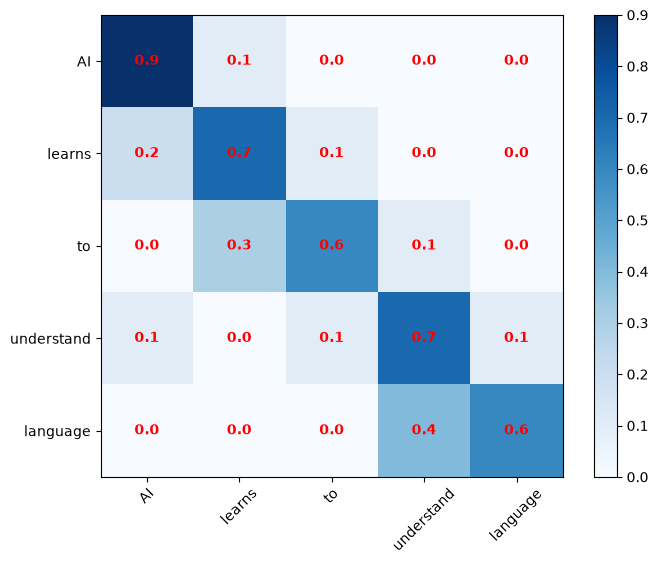

In [2]:
import matplotlib.pyplot as plt
import numpy as np

words = ["AI", "learns", "to", "understand", "language"]
attention_matrix = np.array([
    [0.9, 0.1, 0.0, 0.0, 0.0],  
    [0.2, 0.7, 0.1, 0.0, 0.0],  
    [0.0, 0.3, 0.6, 0.1, 0.0],  
    [0.1, 0.0, 0.1, 0.7, 0.1],  
    [0.0, 0.0, 0.0, 0.4, 0.6],  
])

plt.figure(figsize=(8, 6))
plt.imshow(attention_matrix, cmap='Blues')
plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f'{attention_matrix[i,j]:.1f}',
                ha='center', va='center', color='red', fontweight='bold')

plt.show()


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:

    def __init__(self, d_model=512):
        self.d_model = d_model

    def step_by_step_attention(self, sentence):
        
        words = sentence.split()
        vocab_size = len(words)

        embeddings = torch.randn(vocab_size, self.d_model)
        for i, word in enumerate(words):
            print(word, embeddings[i][:5].tolist())

        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @ W_q  
        K = embeddings @ W_k  
        V = embeddings @ W_v  

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)  
        print(scores.shape)

        attention_weights = F.softmax(scores, dim=-1)


        plt.figure(figsize=(10, 8))
        plt.imshow(attention_weights.detach().numpy(), cmap='Blues')
        plt.xticks(range(len(words)), words, rotation=45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f'{attention_weights[i,j]:.2f}',
                        ha='center', va='center',
                        color='red' if attention_weights[i,j] > 0.3 else 'black')

        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()

        return output, attention_weights

def run_attention_demo():
    
    explainer = SelfAttentionExplainer()

    sentences = [
        "The cat sat on the mat",
        "AI learns to understand language",
        "Transformer models revolutionized NLP"
    ]

    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)




In [4]:
class PracticalAttentionExample:

    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=512,
            num_heads=8,
            batch_first=True
        )

    def text_classification_with_attention(self):
        
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)

        attn_output, attn_weights = self.multihead_attn(
            text_embeddings, text_embeddings, text_embeddings
        )

        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)

        classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 3)  
        )

        pooled = attn_output.mean(dim=1)  
        predictions = classifier(pooled)  

        print(predictions.shape)

        return predictions


The [0.6721079349517822, -0.5496140122413635, -1.5190716981887817, -1.6473397016525269, 1.3739062547683716]
cat [0.5844455361366272, -0.6242448687553406, -0.1457703411579132, -0.6992061138153076, -0.10746603459119797]
sat [0.7139660120010376, -2.14042067527771, 1.0770461559295654, 0.23197339475154877, -0.10467902570962906]
on [0.6842975616455078, -0.42640089988708496, -0.16923819482326508, 0.7067752480506897, -1.528053641319275]
the [0.23048315942287445, -0.8235576748847961, 1.2007390260696411, -0.13430382311344147, 0.1540071964263916]
mat [-1.1847831010818481, 0.09002320468425751, -1.4333622455596924, -0.9305953979492188, -1.256268858909607]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 6])


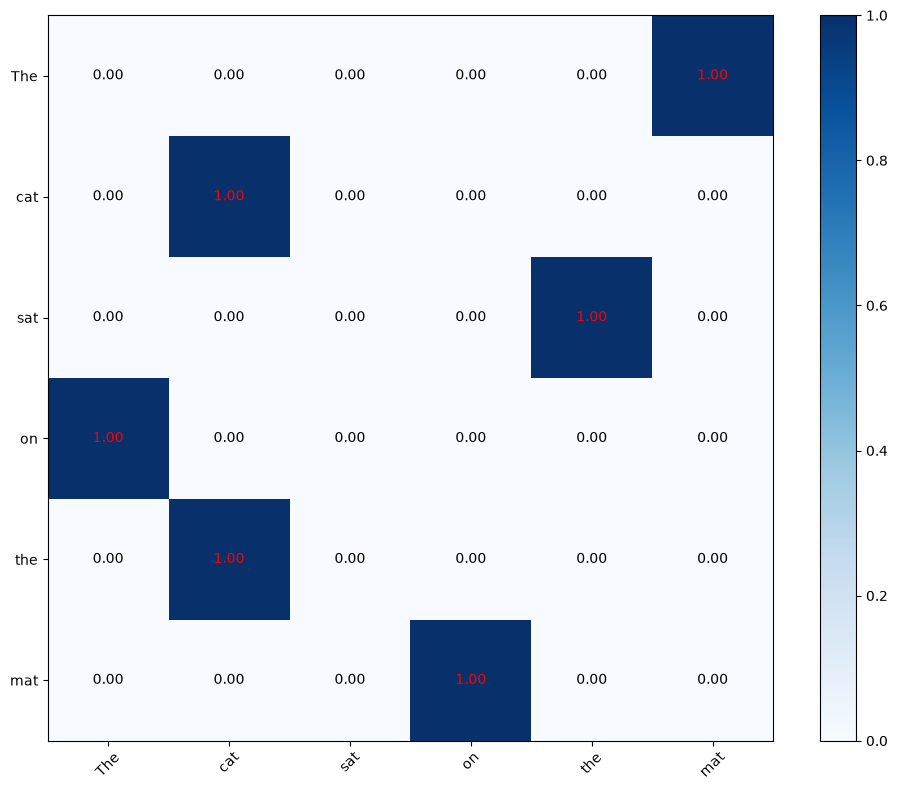

torch.Size([6, 512])
AI [-1.981894612312317, -0.6629338264465332, 0.08171998709440231, -0.4400169551372528, 1.5977795124053955]
learns [0.439511239528656, 1.0430188179016113, -0.7508772015571594, -0.11168068647384644, -1.547313928604126]
to [-1.7383500337600708, -0.5837304592132568, 0.38036611676216125, 0.44084253907203674, -1.1014082431793213]
understand [-0.03173884376883507, 0.8856848478317261, -0.6714290380477905, 0.9747064709663391, 1.1372427940368652]
language [0.5372298955917358, -0.27926191687583923, -0.4802401661872864, -0.8816508054733276, 0.341948926448822]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 5])


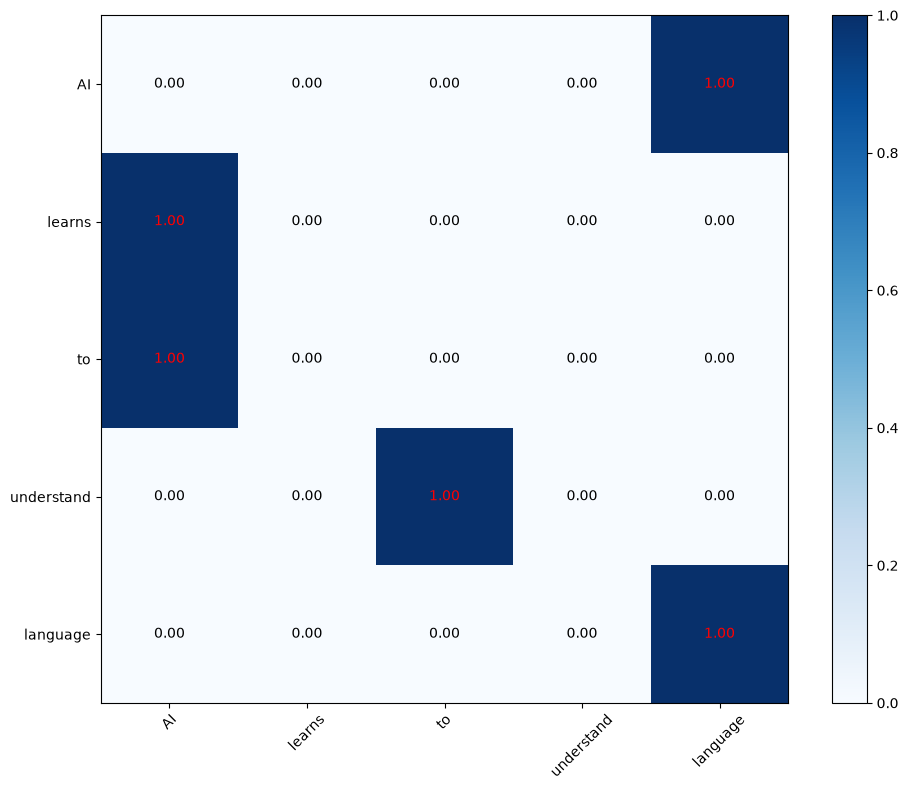

torch.Size([5, 512])
Transformer [0.5568968653678894, 0.5795313715934753, -0.06774704903364182, -0.3306211829185486, 0.47066962718963623]
models [0.4225778877735138, 0.9284590482711792, -0.14420445263385773, -0.1247248649597168, 1.2041364908218384]
revolutionized [1.1837725639343262, 0.218690425157547, 0.5896934270858765, -0.034774962812662125, 0.5435860753059387]
NLP [0.9652935266494751, 1.6796391010284424, 1.1841434240341187, 0.6160277128219604, -1.7627207040786743]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 4])


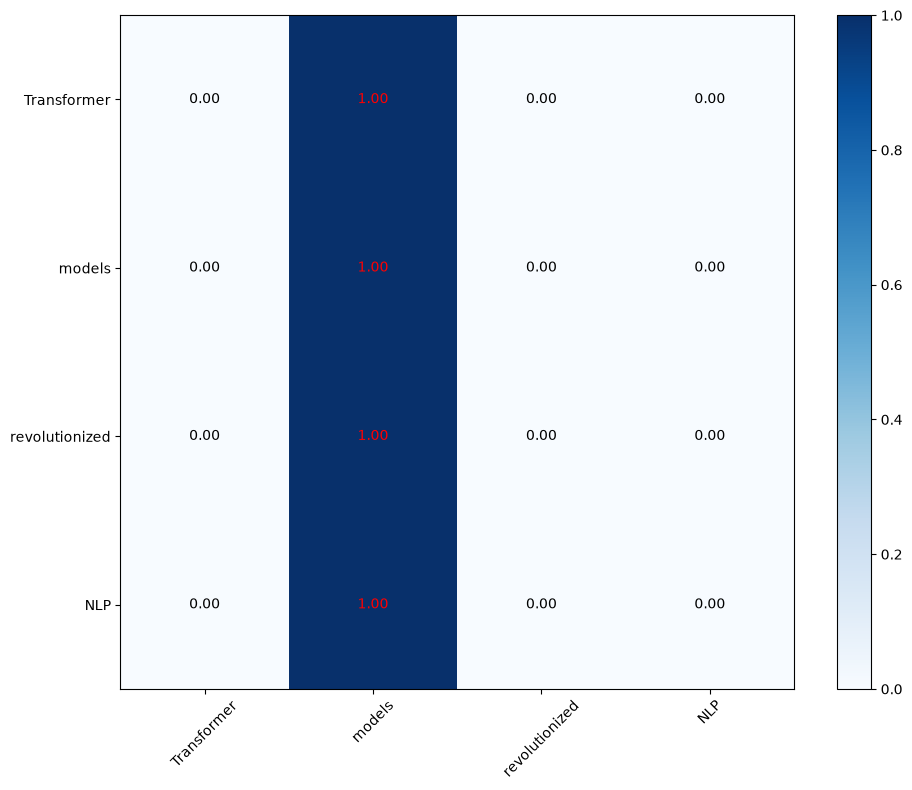

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[ 0.0884, -0.0280, -0.0135],
        [ 0.0732, -0.0482, -0.0094]], grad_fn=<AddmmBackward0>)

In [5]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()

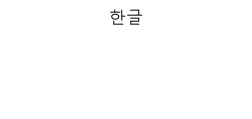

In [6]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(3, 1))
plt.title("한글")
plt.axis('off')
plt.show()

In [7]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

sentence = "This movie was fantastic!"
inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim=1)
print(predicted_class.item())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\KDS-22\Documents\17_Study\17_딥러닝\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KDS-22\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1


In [8]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained=True)

num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

img = Image.open("example.jpg").convert("RGB")
img_t = transform(img)
img_t = img_t.unsqueeze(0)  

outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

c:\Users\KDS-22\Documents\17_Study\17_딥러닝\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KDS-22\Documents\17_Study\17_딥러닝\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\KDS-22/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 91.8MB/s]


FileNotFoundError: [Errno 2] No such file or directory: 'example.jpg'

In [10]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sentences = ["I love this movie", "I hate this movie", "It was okay", "Fantastic film", "Terrible experience"]
labels = torch.tensor([1, 0, 1, 1, 0])  

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
dataset = TensorDataset(encoded_inputs['input_ids'], labels)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

model_fe = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
for param in model_fe.bert.parameters():
    param.requires_grad = False
optimizer_fe = optim.Adam(model_fe.parameters(), lr=2e-5)

model_ft = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=2e-5)

def train_model(model, optimizer, epochs=3):
    model.train()
    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, labels=label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
        print(epoch+1, loss.item())

train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1 1.0249404907226562
2 0.5268304347991943
3 0.981574535369873
1 0.6443573236465454
2 0.6040210723876953
3 0.6345320343971252
